<a href="https://colab.research.google.com/github/shahwaiz-9/Deep-Learning/blob/main/Hybrid_(_CNN's_%2B_LSTM_)_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [31]:
!pip install opencv-python

In [24]:
import os
import numpy as np
import cv2
import pandas as pd
from sklearn.preprocessing import LabelEncoder

In [32]:
import tensorflow as tf
from tensorflow.keras.applications import resnet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import Input, GlobalAveragePooling2D, LSTM, Dense , Dropout

In [25]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("matthewjansen/ucf101-action-recognition")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'ucf101-action-recognition' dataset.
Path to dataset files: /kaggle/input/ucf101-action-recognition


The dataset has been downloaded. Now let's inspect the contents of the directory to understand how to load the actual data.

In [26]:

# train_csv = pd.read_csv('/root/.cache/kagglehub/datasets/matthewjansen/ucf101-action-recognition/versions/4/train.csv')


train_csv = pd.read_csv('/kaggle/input/ucf101-action-recognition/train.csv')

train_csv.head()

,clip_name,clip_path,label
0,v_Swing_g05_c02,/train/Swing/v_Swing_g05_c02.avi,Swing
1,v_Swing_g21_c03,/train/Swing/v_Swing_g21_c03.avi,Swing
2,v_Swing_g07_c01,/train/Swing/v_Swing_g07_c01.avi,Swing
3,v_Swing_g24_c04,/train/Swing/v_Swing_g24_c04.avi,Swing
4,v_Swing_g20_c03,/train/Swing/v_Swing_g20_c03.avi,Swing


In [27]:
train_csv.shape

(10055, 3)

In [28]:
train_csv['label'].unique()

array(['Swing', 'SkyDiving', 'BreastStroke', 'TableTennisShot',
       'FloorGymnastics', 'Rowing', 'SoccerJuggling', 'BenchPress',
       'TennisSwing', 'FrisbeeCatch', 'Kayaking', 'ApplyLipstick',
       'RopeClimbing', 'JumpingJack', 'BlowingCandles', 'BabyCrawling',
       'HammerThrow', 'BoxingPunchingBag', 'Skiing', 'UnevenBars',
       'PullUps', 'RockClimbingIndoor', 'HeadMassage', 'HulaHoop',
       'Rafting', 'ShavingBeard', 'LongJump', 'FieldHockeyPenalty',
       'VolleyballSpiking', 'Punch', 'Archery', 'PlayingDhol',
       'CleanAndJerk', 'PlayingDaf', 'GolfSwing', 'PlayingSitar',
       'IceDancing', 'SkateBoarding', 'BodyWeightSquats',
       'HandstandPushups', 'BalanceBeam', 'WallPushups', 'HorseRiding',
       'Bowling', 'JumpRope', 'CuttingInKitchen', 'CliffDiving',
       'PlayingGuitar', 'FrontCrawl', 'HandstandWalking', 'Fencing',
       'Basketball', 'Typing', 'TaiChi', 'PlayingCello', 'Lunges',
       'Shotput', 'Nunchucks', 'ApplyEyeMakeup', 'BaseballPitch',
 

In [29]:
shrinked = train_csv[
    (train_csv['label'] == "TennisSwing") |
    (train_csv['label'] == "HorseRiding") |
    (train_csv['label'] == "PlayingPiano") |
    (train_csv['label'] == "BrushingTeeth") |
    (train_csv['label'] == "PlayingCello") |
    (train_csv['label'] == "PlayingViolin")
]

In [30]:
shrinked.shape

(621, 3)

**Resnet for transfer learning**

In [33]:
base_model = resnet50.ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)


feature_extractor = Model(base_model.input, GlobalAveragePooling2D()(base_model.output)) # Getting the last convo filters in this case 2058 for each frame
feature_extractor.trainable = False

**Making frame sequences using openCV**

In [34]:
def load_video_data(video_path):

    base_dataset_path = path
    full_video_path = os.path.join(base_dataset_path, video_path.lstrip('/'))

    cap = cv2.VideoCapture(full_video_path)

    # Uniform 20 frames per video
    frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    step = max(1, frame_count // 20)  # Even spacing

    frames = []
    target_size = (224, 224)  # Standard for VGG/ResNet

    for i in range(0, frame_count, step):
        cap.set(cv2.CAP_PROP_POS_FRAMES, i)
        ret, frame = cap.read()
        if ret:
            frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            frame = cv2.resize(frame, target_size)
            frames.append(frame)
            if len(frames) == 20:
                break

    cap.release()

    # Pad if fewer than 20
    while len(frames) < 20:
        frames.append(frames[-1] if frames else np.zeros(target_size + (3,), dtype=np.uint8))

    return np.array(frames)  # Shape: (20, 224, 224, 3)

**Custom generator to optimize memory consumption**

In [35]:


class VideoFrameGenerator(tf.keras.utils.Sequence):
    def __init__(self, dataframe, feature_extractor_model, batch_size=32, shuffle=True):
        self.dataframe = dataframe.reset_index(drop=True)
        self.feature_extractor = feature_extractor_model
        self.batch_size = batch_size
        self.shuffle = shuffle
        self.on_epoch_end()

    def __len__(self):
        return int(np.floor(len(self.dataframe) / self.batch_size))

    def __getitem__(self, index):
        indexes = self.indexes[index * self.batch_size:(index + 1) * self.batch_size]
        batch_df = self.dataframe.iloc[indexes]

        X, y = self.__data_generation(batch_df, indexes)
        return X, y

    def on_epoch_end(self):
        self.indexes = np.arange(len(self.dataframe))
        if self.shuffle == True:
            np.random.shuffle(self.indexes)

    def __data_generation(self, batch_df, original_indexes):

        X_batch = []
        y_batch = batch_df['label'].values

        # Process each video in the batch
        for i, clip_path in enumerate(batch_df['clip_path']):

            video_frames = load_video_data(clip_path)

            processed_frames = preprocess_input(video_frames)

            # Extract features for the current video's frames
            video_features = self.feature_extractor.predict(processed_frames, verbose=0)
            X_batch.append(video_features)

        X_batch = np.array(X_batch)

        return X_batch, y_batch

In [36]:

shrinked['label'].unique()
le = LabelEncoder()
shrinked['label'] = le.fit_transform(shrinked['label'])
shrinked['label'].unique()

/tmp/ipykernel_26246/469123434.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  shrinked['label'] = le.fit_transform(shrinked['label'])


array([5, 1, 2, 3, 0, 4])

In [37]:
from sklearn.model_selection import train_test_split

train_df, val_df = train_test_split(shrinked, test_size=0.2, random_state=42)


train_generator_fixed = VideoFrameGenerator(
    dataframe=train_df,
    feature_extractor_model=feature_extractor,
    batch_size=8,
    shuffle=True
)

validation_generator = VideoFrameGenerator(
    dataframe=val_df,
    feature_extractor_model=feature_extractor,
    batch_size=8,
    shuffle=False
)

example_batch_X, example_batch_y = train_generator_fixed[0]


In [39]:



input_shape_lstm = (example_batch_X.shape[1], example_batch_X.shape[2]) # (20, 2048)

print("Input Shape: ", input_shape_lstm)

# Number of classes for the output layer
num_classes = len(shrinked['label'].unique())

# Build the LSTM model
model = Sequential([
    LSTM(128, input_shape=input_shape_lstm, activation='relu'),
    Dropout(0.5), # Add dropout for regularization
    Dense(num_classes, activation='softmax') # Output layer for classification
])


model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


model.summary()

Input Shape:  (20, 2048)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 128)            │     1,114,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,115,398 (4.25 MB)

 Trainable params: 1,115,398 (4.25 MB)

 Non-trainable params: 0 (0.00 B)

In [40]:
train_generator_fixed[0]

(array([[[1.86362013e-01, 7.58389980e-02, 9.72185936e-03, ...,
          2.30889583e+00, 1.59509689e-01, 2.66459584e-01],
         [3.38362694e-01, 6.28828183e-02, 3.44334170e-02, ...,
          2.78135014e+00, 3.46052736e-01, 3.88496637e-01],
         [3.17856461e-01, 1.58736743e-02, 1.28769604e-02, ...,
          2.71440721e+00, 1.65439606e-01, 4.26528066e-01],
         ...,
         [2.81420410e-01, 1.97624728e-01, 0.00000000e+00, ...,
          2.87794638e+00, 6.27050996e-02, 1.71938986e-01],
         [2.03504190e-01, 1.10519409e-01, 9.11052804e-03, ...,
          2.60511589e+00, 3.13332342e-02, 1.06421381e-01],
         [1.09787948e-01, 6.96665868e-02, 9.30505060e-03, ...,
          2.61499166e+00, 3.15480232e-01, 1.70427322e-01]],
 
        [[4.70994890e-01, 1.92263556e+00, 2.20704496e-01, ...,
          3.12777090e+00, 1.44328833e+00, 7.39341438e-01],
         [3.73771280e-01, 2.49975204e+00, 1.87243029e-01, ...,
          3.72153974e+00, 1.83856547e-01, 1.39073741e+00],
       

In [41]:

history = model.fit(
    train_generator_fixed,
    epochs=10,
    validation_data=validation_generator,
    batch_size=8,
    verbose = 0
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


In [49]:
history.history


{'accuracy': [0.24395161867141724,
  0.32258063554763794,
  0.5443548560142517,
  0.6754032373428345,
  0.725806474685669,
  0.7782257795333862,
  0.8084677457809448,
  0.8165322542190552,
  0.8629032373428345,
  0.899193525314331],
 'loss': [30.21077537536621,
  5.709954261779785,
  1.503132939338684,
  0.9131636619567871,
  0.7853584289550781,
  0.5526496171951294,
  0.5561982989311218,
  0.44474807381629944,
  0.3149842917919159,
  0.28784021735191345],
 'val_accuracy': [0.21666666865348816,
  0.5916666388511658,
  0.8333333134651184,
  0.8666666746139526,
  0.9083333611488342,
  0.949999988079071,
  0.9583333134651184,
  0.949999988079071,
  0.9750000238418579,
  0.9916666746139526],
 'val_loss': [6.617080211639404,
  1.1194729804992676,
  0.5948686599731445,
  0.44464823603630066,
  0.4352598488330841,
  0.24267150461673737,
  0.31031495332717896,
  0.16361525654792786,
  0.10512365400791168,
  0.08111439645290375]}

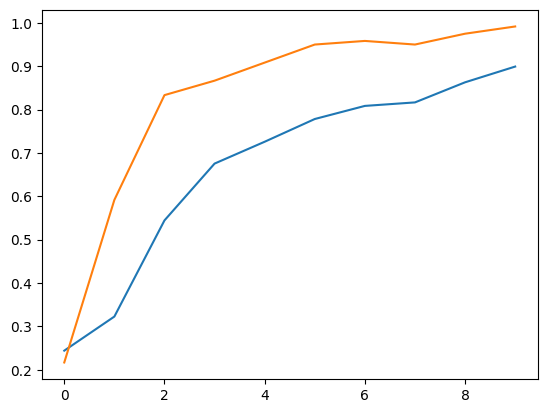

In [47]:
import matplotlib.pyplot as plt

# Plot training & validation accuracy values
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])


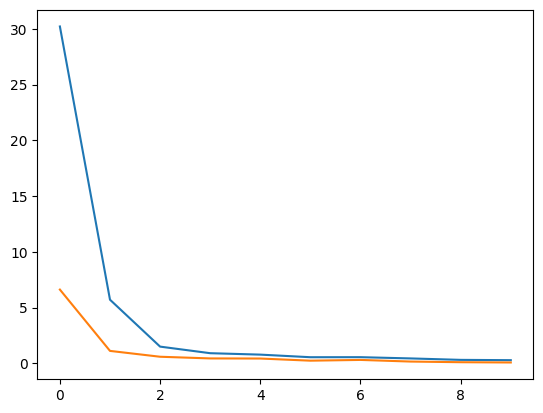

In [48]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

The most stable training i ever had!